<a href="https://colab.research.google.com/github/Arhanabdullah/College-ML-Assignment/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Month with highest attendance: November
Highest attendance: 94 %
Average attendance: 87.92 %


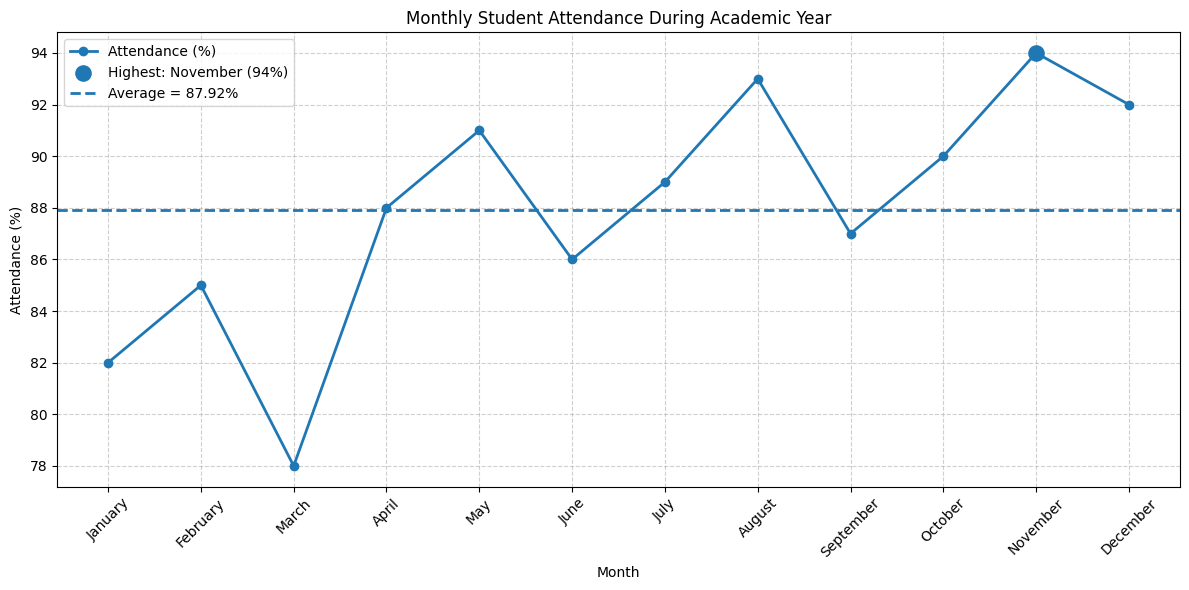

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
attendance = [82, 85, 78, 88, 91, 86, 89, 93, 87, 90, 94, 92]
# Calculate average attendance
average_attendance = np.mean(attendance)
# Find highest attendance
highest_attendance = max(attendance)
highest_index = attendance.index(highest_attendance)
highest_month = months[highest_index]
# Print results
print("Month with highest attendance:", highest_month)
print("Highest attendance:", highest_attendance, "%")
print("Average attendance:", round(average_attendance, 2), "%")
# Create line plot
plt.figure(figsize=(12, 6))
plt.plot(
    months,
    attendance,
    marker="o",
    linewidth=2,
    label="Attendance (%)"
)
# Highlight highest attendance
plt.scatter(
    highest_month,
    highest_attendance,
    s=120,
    label=f"Highest: {highest_month} ({highest_attendance}%)",
    zorder=5
)
# Horizontal average reference line
plt.axhline(
    average_attendance,
    linestyle="--",
    linewidth=2,
    label=f"Average = {average_attendance:.2f}%"
)
# Labels and title
plt.title("Monthly Student Attendance During Academic Year")
plt.xlabel("Month")
plt.ylabel("Attendance (%)")
# Rotate month labels
plt.xticks(rotation=45)
# Grid
plt.grid(True, linestyle="--", alpha=0.6)
# Legend
plt.legend()
plt.tight_layout()
plt.show()

Employee Data:
   Experience  Salary Department
0           1     3.2        CSE
1           2     4.1        ECE
2           3     5.0        CSE
3           4     5.8         IT
4           5     6.5        CSE
5           6     7.2        ECE
6           7     8.1         IT
7           8     9.0        CSE
8           9     9.8        ECE
9          10    11.0         IT


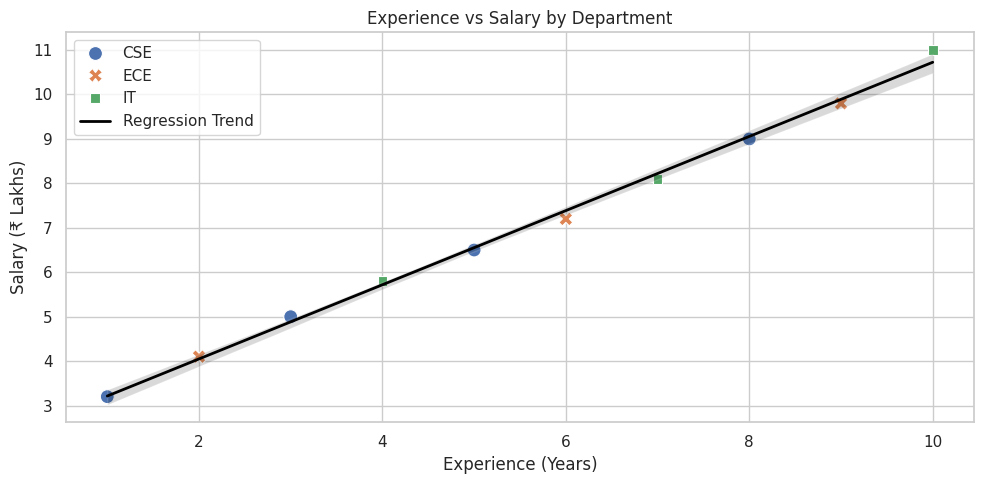

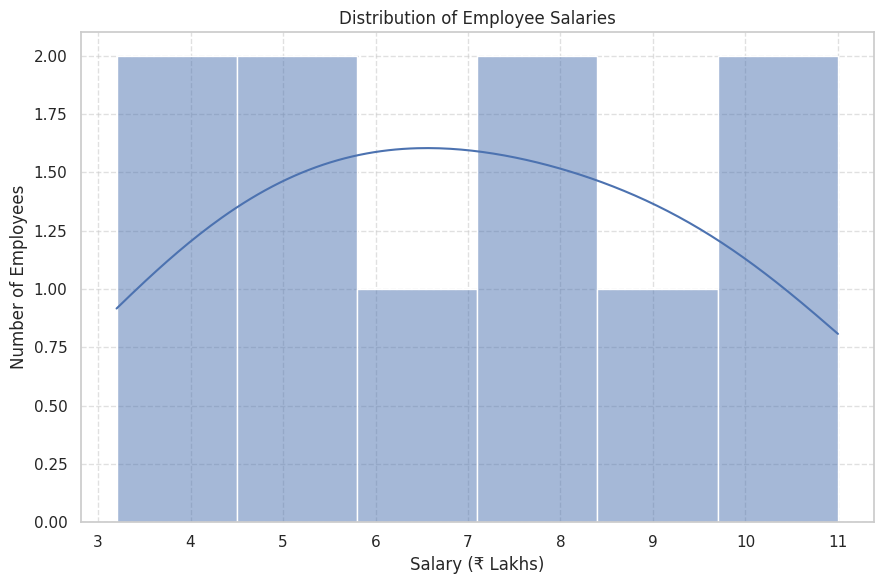

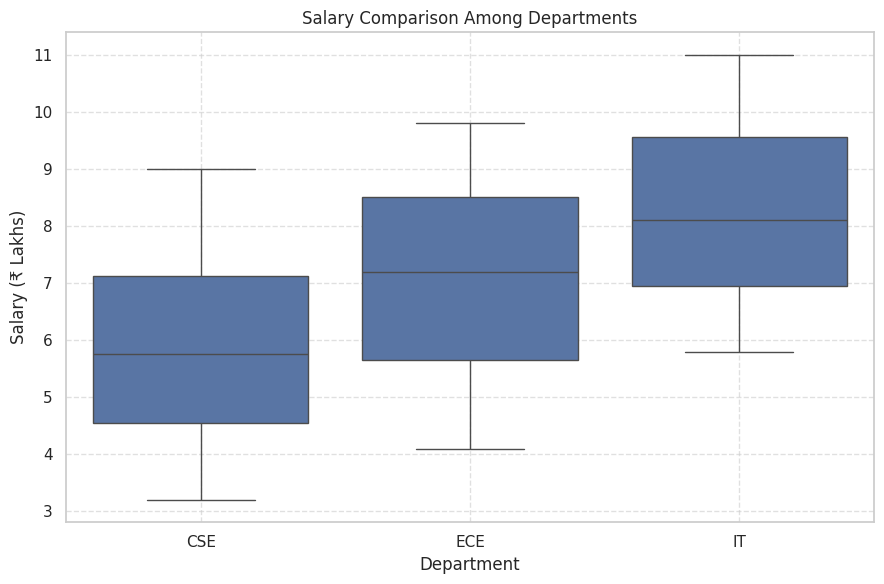


Observations:
1. Salary increases as the years of experience increase.
2. Employee salaries range from ₹3.2 lakhs to ₹11.0 lakhs.
3. Salaries of different departments overlap, indicating that experience
   appears to have a stronger relationship with salary in this dataset.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Create DataFrame
df = pd.DataFrame({
    "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Salary": [3.2, 4.1, 5.0, 5.8, 6.5, 7.2, 8.1, 9.0, 9.8, 11.0],
    "Department": [
        "CSE", "ECE", "CSE", "IT", "CSE",
        "ECE", "IT", "CSE", "ECE", "IT"
    ]
})
print("Employee Data:")
print(df)
# Set Seaborn style
sns.set_theme(style="whitegrid")
# 1-4. Scatter plot with regression trend line
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="Experience",
    y="Salary",
    hue="Department",
    style="Department",
    s=100
)
sns.regplot(
    data=df,
    x="Experience",
    y="Salary",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2},
    label="Regression Trend"
)
plt.title("Experience vs Salary by Department")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (₹ Lakhs)")
plt.legend()
plt.tight_layout()
plt.show()
print('\n\n')
# 5. Salary distribution
plt.figure(figsize=(9, 6))
sns.histplot(
    data=df,
    x="Salary",
    bins=6,
    kde=True
)
plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary (₹ Lakhs)")
plt.ylabel("Number of Employees")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
print('\n\n')
# 6. Box plot
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="Department",
    y="Salary"
)
plt.title("Salary Comparison Among Departments")
plt.xlabel("Department")
plt.ylabel("Salary (₹ Lakhs)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
print('\n\n')
# 7. Observations
print("\nObservations:")
print("1. Salary increases as the years of experience increase.")
print("2. Employee salaries range from ₹3.2 lakhs to ₹11.0 lakhs.")
print("3. Salaries of different departments overlap, indicating that experience")
print("   appears to have a stronger relationship with salary in this dataset.")

House Price Dataset:
    Area  Price
0    800     32
1   1000     40
2   1200     48
3   1400     55
4   1600     63
5   1800     70
6   2000     78
7   2200     85
8   2400     94
9   2600    102
10  2800    110
11  3000    118

Basic Statistical Analysis:
              Area       Price
count    12.000000   12.000000
mean   1900.000000   74.583333
std     721.110255   28.030692
min     800.000000   32.000000
25%    1350.000000   53.250000
50%    1900.000000   74.000000
75%    2450.000000   96.000000
max    3000.000000  118.000000

Missing Values:
Area     0
Price    0
dtype: int64

Linear Regression Model:
Coefficient (Slope): 0.03873603351955306
Intercept: 0.8868715083798975

Actual vs Predicted Prices:
 Area (sq.ft.)  Actual Price (₹ Lakhs)  Predicted Price (₹ Lakhs)
           800                      32                  31.875698
          2600                     102                 101.600559
          2800                     110                 109.347765

Evaluation Metrics:


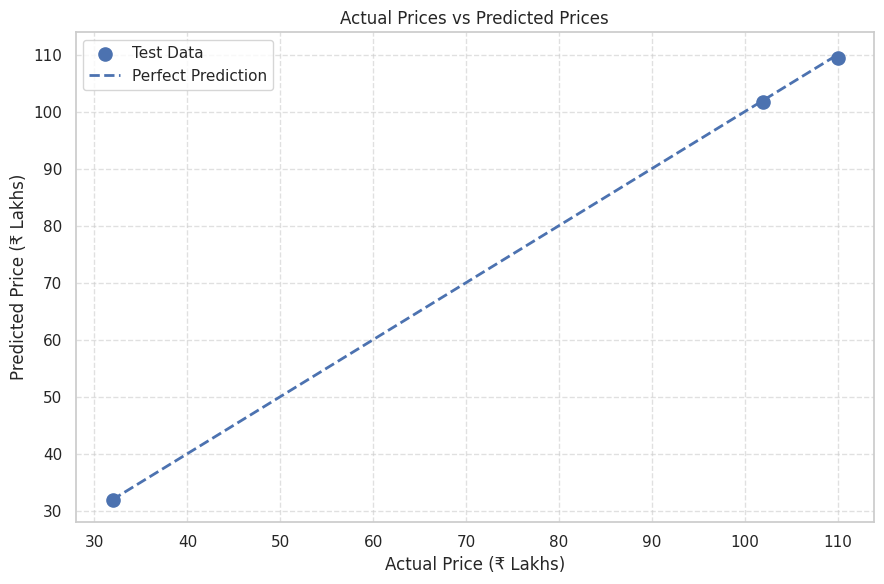

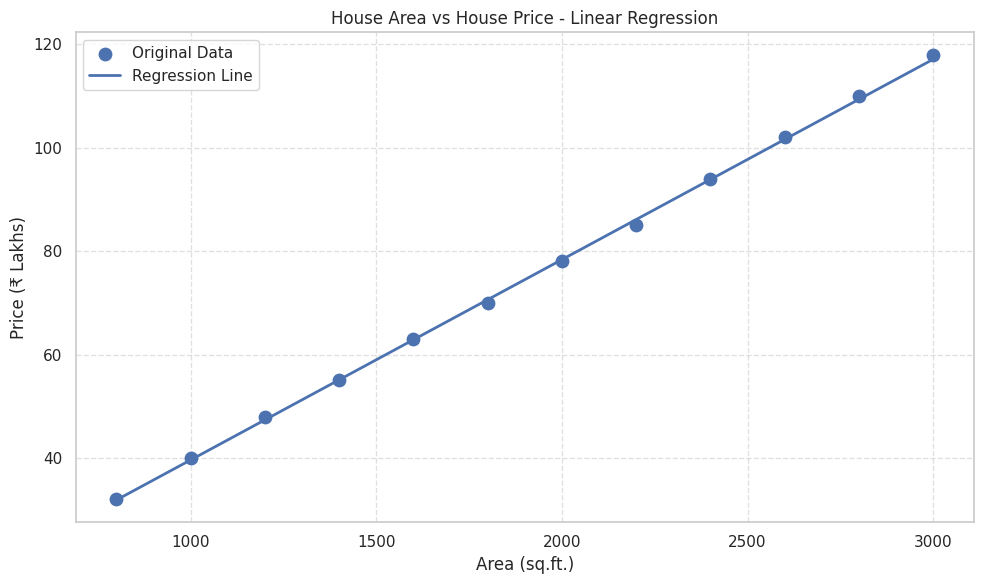





Predicted price for 2500 sq.ft.: 97.72695530726256 Lakhs

Conclusion:
The model provides a very good fit because the R²
score is very close to 1 and the prediction errors are small.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# 1. Create Pandas DataFrame
df = pd.DataFrame({
    "Area": [
        800, 1000, 1200, 1400, 1600, 1800,
        2000, 2200, 2400, 2600, 2800, 3000
    ],
    "Price": [
        32, 40, 48, 55, 63, 70,
        78, 85, 94, 102, 110, 118
    ]
})
print("House Price Dataset:")
print(df)
# 2. Basic Data Analysis
print("\nBasic Statistical Analysis:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
# 3. Separate Features and Target
X = df[["Area"]]
y = df["Price"]
# 4. Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# 5. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
# 6. Display Coefficient and Intercept
coefficient = model.coef_[0]
intercept = model.intercept_
print("\nLinear Regression Model:")
print("Coefficient (Slope):", coefficient)
print("Intercept:", intercept)
# 7. Predict prices for test data
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Area (sq.ft.)": X_test["Area"].values,
    "Actual Price (₹ Lakhs)": y_test.values,
    "Predicted Price (₹ Lakhs)": y_pred
})
comparison = comparison.sort_values("Area (sq.ft.)")
print("\nActual vs Predicted Prices:")
print(comparison.to_string(index=False))
# 8. Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
# 9. Actual Prices vs Predicted Prices
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred,
    s=90,
    label="Test Data"
)
# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)
plt.title("Actual Prices vs Predicted Prices")
plt.xlabel("Actual Price (₹ Lakhs)")
plt.ylabel("Predicted Price (₹ Lakhs)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
print('\n\n')
# 10. Regression Line with Original Data
x_line = np.linspace(
    df["Area"].min(),
    df["Area"].max(),
    200
)
y_line = model.predict(
    pd.DataFrame({"Area": x_line})
)
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Area"],
    df["Price"],
    s=80,
    label="Original Data"
)
plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Regression Line"
)
plt.title("House Area vs House Price - Linear Regression")
plt.xlabel("Area (sq.ft.)")
plt.ylabel("Price (₹ Lakhs)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
print('\n\n')
# 11. Predict price for 2500 sq.ft.
new_house = pd.DataFrame({
    "Area": [2500]
})
predicted_price = model.predict(new_house)

print("\nPredicted price for 2500 sq.ft.:",
      predicted_price[0], "Lakhs")
# 12. Conclusion
if r2 >= 0.90:
    print("\nConclusion:")
    print("The model provides a very good fit because the R²")
    print("score is very close to 1 and the prediction errors are small.")
else:
    print("\nConclusion:")
    print("The model does not provide a very strong fit.")